<a href="https://colab.research.google.com/github/Merenguimona/act2IA/blob/main/Copia_de_Integraci%C3%B3n_apartado_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://upload.wikimedia.org/wikipedia/commons/4/42/UNIR_Horizontal_Logo.png style= "width: 300px; float: right; margin-right: 10px;">

# __ACTIVIDAD 2 - APARTADO B__
**ASIGNATURA: TÉCNICAS DE INTELIGENCIA ARTIFICIAL**

DOCENTE : ADRIANA CERVANTES CASTILLO

ESTUDIANTES:

- SUSANA ALFARO LIRA
- JOSE CHABLÉ DE LA CRUZ
- JAFETH LEYVA REYNA
- WANDER PAYANO LINARES
- LUIS VEGA CABALLERO


Fecha de entrega: 13 de abril de 2026

## **Objetivos de la actividad**

Esta actividad tiene por objetivo profundizar en la aplicación de técnicas de aprendizaje supervisado (regresión y clasificación), basadas en redes neuronales utilizando las librerías de `Keras` y `TensorFlow` sobre `Python`.

Para ello, como grupo de trabajo se deben de escoger dos *dataset* de plataformas online en base a requisitos mínimos y aplicando los siguientes modelos:

1. **Primer caso - Regresión comparada**: utilizar una red neuronal para realizar una regresión comparada con otra técnica no basada en redes neuronales.
2.   **Segundo caso - Clasificación**: utilizar una red neuronal diferente para la clasificación, de nuevo comparada con otra red de clasificación no basada en redes neuronales, cuya variable objetivo posea al menos 5 clases para la clasificación.


El presente apartado corresponde al segundo caso de clasificación.


## **Pautas de elaboración**

Se deberan utilizar, al menos, las siguientes librerías:
- `Pandas` para la importación de datos
- `Keras` sobre `TensorFlow 2.0` (tensorflow.keras)
- Por último el grupo podrá utilizar otras librerias necesarias para trabajar con los modelos escogidos y distintos a los de redes neuronales.



## **Diseño Experimental de Apartado B - Ejercicio de Clasificación**

### **Dataset**

Para el siguiente trabajo se utilizó el dataset llamado "Social Media Addiction vs Productivity Dataset", disponible en [kaggle](https://www.kaggle.com/datasets/asifxzaman/social-media-addiction-vs-productivity-dataset).

Este dataset se ha cargado en un GitHub de un miembro del equipo y se encuentra disponible en la siguiente [url](https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/social_media_productivity_6000.csv).

El dataframe resultante de este archivo csv, con separador "," se nombro como `dt_SocialMediaP`.

.

### **Características del dataset y variable objetiva**

Las características del dataset se analizó a traves de la librería `pandas`, este posee 6000 elementos distribuidos en 9 categorías de información:

|Nombre|Descripción de variable|Tipo de dato|
|------|-----------------------|-----------|
|age   | edad del individuo     | Float      |
|daily_screen_time| Tiempo total en pantalla, en horas| Float|
|study_hours| Tiempo de trabajoproductivo/tiempo de estudio, en horas|Float|
|sleep_hours|Horas de sueño|Float|
|notifications_per_day|Número de notificaciones diarias|Float|
|focus_score|Enfoque mental calculado (0-100)|Float|
|addiction_level| Baja, media y alta| String (Low / Medium / High)|
|productivity_score| Puntuación de productividad (0-100)| Float|

Como variable objetiva, se propuso crear la variable llamada `productivity level`, para esto se crean cinco intervalos a partir de los datos de `productivity score` con las clases: `Muy baja`, `Baja`, `Media`, `Alta` y `Muy Alta`.

|Rango | Clase |Número de Registros|
|----------|------------ |---|
|0-20 | Muy baja |1843|
| 21-40 | Baja | 1346|
| 41-60 | Media | 1315|
| 61-80 | Alta | 931|
| 81-100 | Muy Alta |445|
.

### **Preprocesamiento de datos**

Se aplicó un proceso de preprocesamiento orientado al tratamiento de valores faltantes y a la codificación de variables categóricas. Los valores nulos de las variables numéricas fueron imputados con la media de cada columna, mientras que los valores faltantes de la variable objetivo addiction_level fueron reemplazados por la moda. Posteriormente, las variables categóricas fueron transformadas a formato numérico mediante LabelEncoder. En el caso de addiction_level, se utilizó una codificación ordinal manual (Low, Medium, High) para preservar la jerarquía natural de sus categorías.

.
### **Normalización y balance de datos**

Con el objetivo de mejorar el desempeño de los modelos de clasificación, se aplicaron técnicas de preprocesamiento orientadas a la normalización de los datos y al balanceo de clases.

En el conjunto de datos se identificó un desbalance en la variable objetivo, donde algunas clases presentan una menor representación en comparación con el resto. Para abordar esta situación, se aplicaron técnicas combinadas de sobremuestreo y submuestreo.

En primer lugar, se utilizó el algoritmo SMOTE (Synthetic Minority Over-sampling Technique), el cual genera nuevos registros sintéticos para las clases minoritarias a partir de la interpolación entre instancias cercanas, aumentando su representación en el conjunto de datos.

Posteriormente, se aplicó una técnica de submuestreo (undersampling), que consiste en reducir el número de instancias de las clases mayoritarias mediante selección aleatoria, con el fin de equilibrar la distribución de las clases.

De esta manera, se obtuvo un conjunto de datos más balanceado, adecuado para el entrenamiento de los modelos de clasificación.
.
### **Modelos utilizados**

**Modelo tradicional**

Como modelo de clasificación no basado en redes neuronales, se implementó un algoritmo de tipo ensemble utilizando Random Forest.

El modelo fue entrenado utilizando el conjunto de datos previamente balanceado mediante técnicas de sobremuestreo y submuestreo, con el fin de mitigar el desbalance de clases.

En cuanto a los parámetros del modelo, se configuró el criterio de división como índice Gini (criterion='gini') y se utilizaron 200 árboles (n_estimators=200). La profundidad máxima de los árboles se limitó a 8 niveles (max_depth=8) para controlar la complejidad del modelo. Además, se estableció un mínimo de 6 muestras para realizar una división (min_samples_split=6) y al menos 2 muestras por hoja (min_samples_leaf=2).

Para la selección de variables en cada división se utilizó la raíz cuadrada del número total de atributos (max_features='sqrt'), y el muestreo de los datos se realizó con reemplazo (bootstrap=True).

Con el objetivo de compensar el desbalance de clases, se utilizó el parámetro class_weight='balanced', ajustando automáticamente los pesos de cada clase durante el entrenamiento. Finalmente, se fijó una semilla de aleatoriedad (random_state=42) para asegurar la reproducibilidad de los resultados.

Para comparar el desempeño de Random Forest con la Red Neuronal, se calcularon métricas de pérdida y precisión. Además, se generó un reporte de clasificación (precisión, recall y F1-score) y una matriz de confusión para analizar el desempeño por clase.

.


**Red basado en redes neuronales para regresiones**

Para el desarrollo del modelo de clasificación se utilizó Python, empleando TensorFlow (Keras) para la construcción de la red neuronal y scikit-learn para el preprocesamiento de los datos.

Las variables predictoras del conjunto previamente balanceado fueron estandarizadas mediante `StandardScaler`, asegurando media cero y desviación estándar unitaria. La variable objetivo se codificó con `LabelEncoder` y posteriormente se transformó a formato `one-hot` mediante `to_categorical`, adecuándola a un problema de clasificación multiclase.

El conjunto de datos se dividió en entrenamiento (80%) y validación (20%) utilizando `train_test_split`, con `random_state=42` y muestreo estratificado para preservar la proporción de clases.

Arquitectura del modelo

Se implementó una red neuronal secuencial (Sequential) con la siguiente estructura:

Capa de entrada: 64 neuronas (ReLU)
Capas ocultas: 32 y 16 neuronas (ReLU)
Regularización: Dropout (0.2) en ambas capas intermedias
Capa de salida: activación Softmax con número de neuronas igual al número de clases

Entrenamiento

El modelo se compiló con función de pérdida categorical_crossentropy, optimizador Adam y métrica de precisión (accuracy). El entrenamiento se realizó durante 50 épocas, con tamaño de lote de 32, utilizando el conjunto de validación para monitorear el desempeño.

Evaluación

El modelo fue evaluado sobre un conjunto de prueba independiente, previamente transformado con los mismos parámetros de escalamiento y codificación. Se calcularon métricas de pérdida y precisión. Además, se generó un reporte de clasificación (precisión, recall y F1-score) y una matriz de confusión para analizar el desempeño por clase.



## Carga de librerias

In [ ]:
#%pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspect
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import tree
#Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.tree import plot_tree

#Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Configuración visual
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Semilla para reproducibilidad
np.random.seed(42)

### Carga de Dataset

In [ ]:
url_SocialMediaP = "https://raw.githubusercontent.com/Merenguimona/act2IA/refs/heads/main/Datasets/social_media_productivity_6000.csv"

dt_SocialMediaP = pd.read_csv(url_SocialMediaP, sep= ",")

print("Primeras filas")
dt_SocialMediaP.head()

Primeras filas


,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


### Descripcion de dataset

In [ ]:
# Descripción estadística del dataset Social Media
dt_SocialMediaP.describe(include="all")

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880,5880.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3064,NaN
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,NaN,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,NaN,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,NaN,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,NaN,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,NaN,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,NaN,58.560000


#### Categorías, valores nulos y tipos de datos

Social Media, cuenta con 6000 instancias, con datos en nueve categorias, todos los datos son de tipo float, con excepción de `addiction_level`, el cual es de tipo sting.
El total, cada categoría presenta 120 valores nulos y cero valores duplicados.

In [ ]:
print("Dimensiones:", dt_SocialMediaP.shape)

print("\nInformación general")
dt_SocialMediaP.info()

print("\nTipos de datos")
print(dt_SocialMediaP.dtypes)

Dimensiones: (6000, 9)

Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB

Tipos de datos
age                      float64
daily_screen_time        float64
social_media_hours       float64
study_hours              float64
sleep_hours              float64
notifications_per_day    float64
focus_scor

## Preprocesamiento de datos

Se realizó una búsqueda de valores nulos por columna y del número de entradas con valores nulos. De las columnas, ocho de nueve poseen 120 valores nulos. Con respecto al número de entradas, el porcentaje de perdida de datos que se tendría al elimnarlas supera el 16%. Por esta razón es que se optó por imputar datos, en los valores nulos, mediante medias y modas, segun fuera el caso.

In [ ]:
print("Valores nulos por columna")
print(dt_SocialMediaP.isnull().sum())

print("\nDuplicados:", dt_SocialMediaP.duplicated().sum())

Valores nulos por columna
age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64

Duplicados: 0


In [ ]:
#Calculo de entradas con valores nulos
total = len(dt_SocialMediaP)
sin_nulos = dt_SocialMediaP.dropna().shape[0]
eliminadas = total - sin_nulos
porcentaje = (eliminadas / total) * 100

print("Total filas:", total)
print("Filas sin nulos:", sin_nulos)
print("Filas que se eliminarían:", eliminadas)
print(f"Porcentaje de pérdida: {porcentaje:.2f}%")

Total filas: 6000
Filas sin nulos: 4999
Filas que se eliminarían: 1001
Porcentaje de pérdida: 16.68%


### Tratamiento de valores nulos mediante técnicas de imputación

Los valores nulos fueron tratados mediante técnicas de imputación. En el caso de variables numéricas, se reemplazaron por la media de cada columna, mientras que para variables categóricas se utilizó la moda. Este enfoque permite conservar la mayor cantidad de datos posible sin eliminar registros completos, evitando la pérdida de información relevante para el entrenamiento de los modelos.



In [ ]:
# Rellenar con la media Valores numericos(float)
dt_SocialMediaP = dt_SocialMediaP.fillna(dt_SocialMediaP.mean(numeric_only=True))

#Rellenar con la moda el addition_level(str)
dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].fillna(
    dt_SocialMediaP["addiction_level"].mode()[0]
)

print("\nNulos después de la imputación:")
print(dt_SocialMediaP.isnull().sum())

print("\nTamaño final:")
print(dt_SocialMediaP.shape)


Nulos después de la imputación:
age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64

Tamaño final:
(6000, 9)


### Transformación de valores string a integer

En la celda siguiente, se realizó la codificación de variables categóricas, utilizando un esquema ordinal para la variable objetivo y codificación mediante LabelEncoder para las variables predictoras.

In [ ]:
#Transformar todo a numerico para mejor análisis.
le = LabelEncoder()
jerarquia = {"Low": 0, "Medium": 1, "High": 2}

# CAMBIO AQUÍ: Usamos una lista para incluir "object" y "str" explícitamente
for col in dt_SocialMediaP.select_dtypes(include=["object"]).columns:
    if col == "addiction_level":
        dt_SocialMediaP[col] = dt_SocialMediaP[col].map(jerarquia)
    else:
        dt_SocialMediaP[col] = le.fit_transform(dt_SocialMediaP[col])

dt_SocialMediaP.info()
#Valores del addiction_level
dt_SocialMediaP['addiction_level'].unique()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    6000 non-null   float64
 1   daily_screen_time      6000 non-null   float64
 2   social_media_hours     6000 non-null   float64
 3   study_hours            6000 non-null   float64
 4   sleep_hours            6000 non-null   float64
 5   notifications_per_day  6000 non-null   float64
 6   focus_score            6000 non-null   float64
 7   addiction_level        6000 non-null   int64  
 8   productivity_score     6000 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 422.0 KB


C:\Users\elvla\AppData\Local\Temp\ipykernel_15760\2323792445.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in dt_SocialMediaP.select_dtypes(include=["object"]).columns:


array([1, 0, 2], dtype=int64)

En el preprocesamiento de datos


....

# Analisis EDA

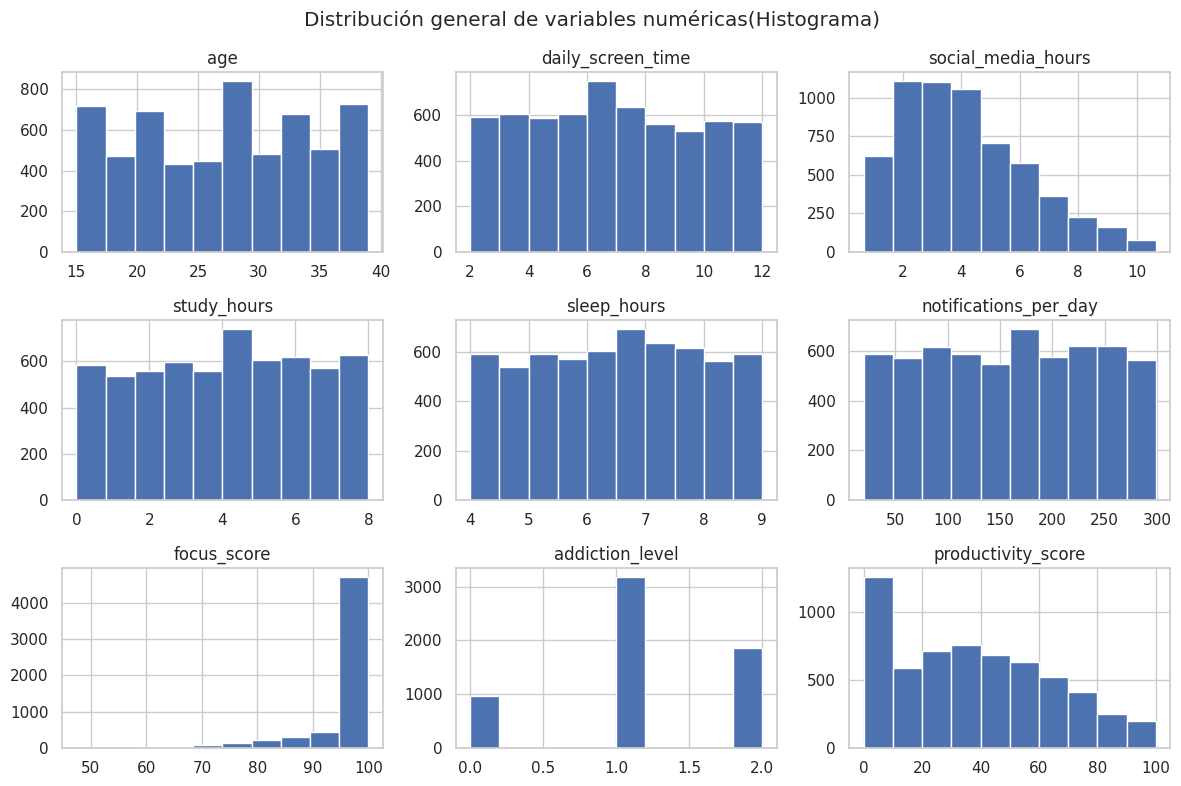

In [ ]:
#Histograma
dt_SocialMediaP.hist(figsize=(12,8))
plt.suptitle("Distribución general de variables numéricas(Histograma)")
plt.tight_layout()
plt.show()

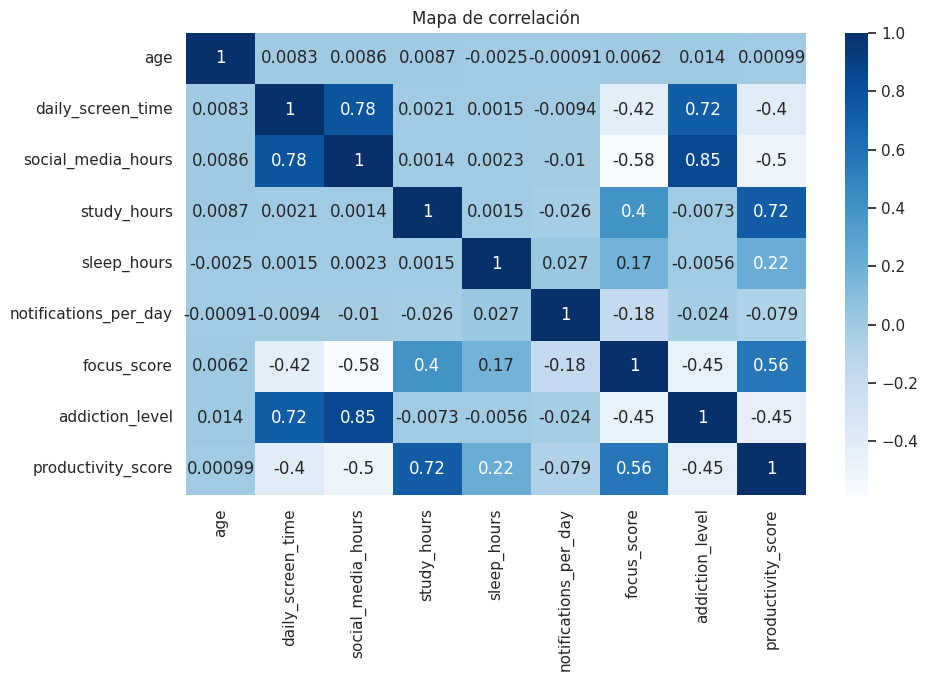

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(
    dt_SocialMediaP.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)
plt.title("Mapa de correlación")
plt.show()

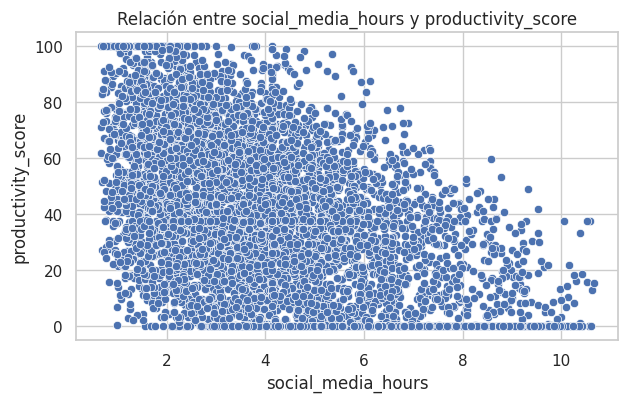

In [ ]:
plt.figure(figsize=(7,4))

sns.scatterplot(
    data=dt_SocialMediaP,
    x="social_media_hours",
    y="productivity_score"
)

plt.title("Relación entre social_media_hours y productivity_score")
plt.show()

Relación inversa

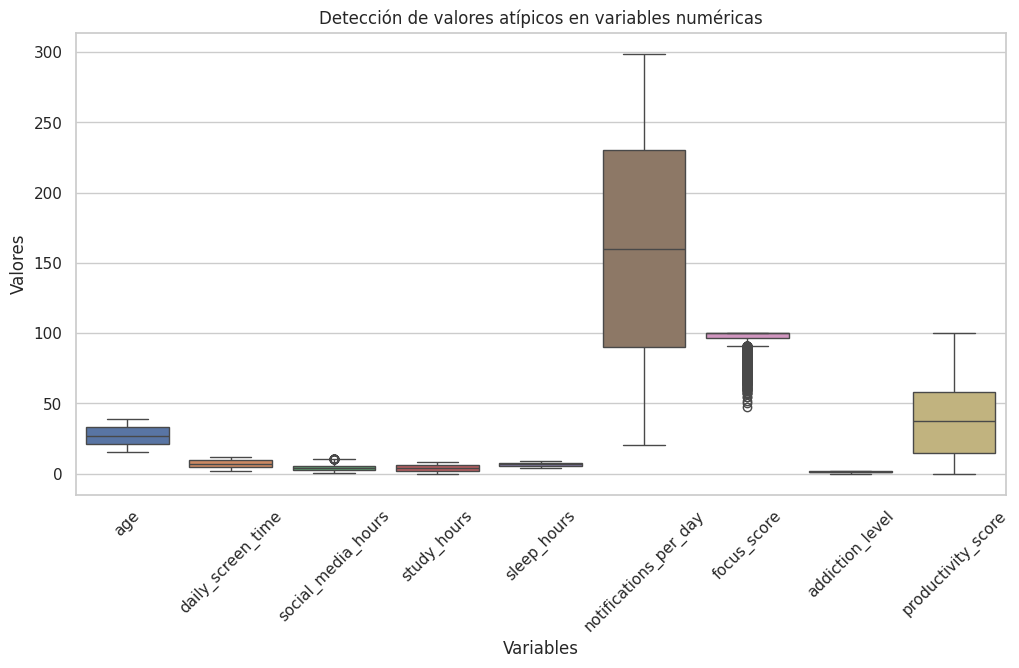

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=dt_SocialMediaP.select_dtypes(include="number"))

plt.xticks(rotation=45)
plt.title("Detección de valores atípicos en variables numéricas")
plt.xlabel("Variables")
plt.ylabel("Valores")

plt.show()

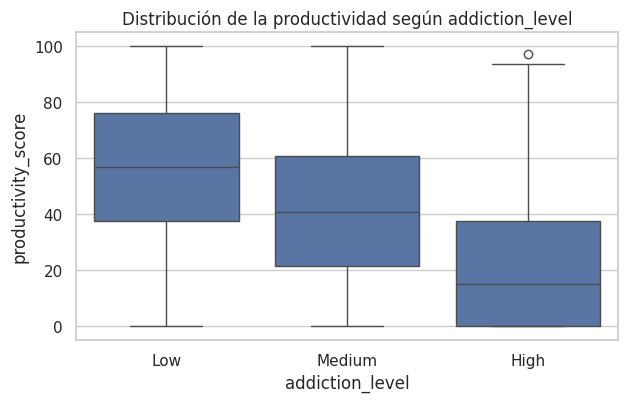

In [ ]:
mapa_adiccion = {0: "Low", 1: "Medium", 2: "High"}

dt_SocialMediaP["addiction_level"] = dt_SocialMediaP["addiction_level"].map(mapa_adiccion)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=dt_SocialMediaP,
    x="addiction_level",
    y="productivity_score",
    order=["Low", "Medium", "High"]
)

plt.title("Distribución de la productividad según addiction_level")
plt.show()

## Hallazgos EDA


Durante el análisis exploratorio preliminar se logran observar 2 variables objetivo **productivity_score** y **addiction_level** siendo estas las de mayor relevancia para el conjunto de datos analizado. De igual manera se observó que las variables numéricas presentan distribuciones relativamente estables, con una mayor concentración de registros en rangos medios de *productivity_score* y *focus_score*, lo que sugiere un comportamiento general consistente en los niveles de productividad y enfoque de los usuarios.

El mapa de correlación evidenció una relación negativa entre *social_media_hours* y *productivity_score*, indicando que, a medida que aumentan las horas dedicadas a redes sociales, la productividad tiende a disminuir. De manera complementaria, la variable *sleep_hours* mostró una asociación positiva con *focus_score*, sugiriendo que mayores horas de descanso se relacionan con mejores niveles de concentración.

Finalmente, el gráfico de distribución de la productividad según *addiction_level* permitió identificar que los usuarios con un nivel de adicción alto (High) presentan medianas de productividad más bajas, reforzando la hipótesis de que un mayor grado de dependencia al uso de redes sociales impacta negativamente en el desempeño de las actividades diarias.

## Métodos de Clasificación no basados en Redes Neuronales
**Propuesta.**
- Predicción de la Productividad

**Variable objetivo**
- productivity_level

**Variables influyentes**
 N  | **Variable**       | **Correlación** | **Interpretación**                      |
 -- |--------------------|-----------------|-----------------------------------------|
 1  | study_hours        | 0.72            | estudiar aumenta productividad          |
 2  | focus_score        | 0.56            | mayor concentración mejora resultados   |
 3  | sleep_hours        | 0.22            | dormir mejor ayuda ligeramente          |
 4  | daily_screen_time  | -0.4            | exceso de pantalla reduce productividad |
 5  | social_media_hours | -0.5            | redes sociales afectan desempeño        |
 6  | addiction_level    | -0.45           | adicción digital reduce productividad   |


**Planteamiento del problema**
- ¿Cómo predecir la productividad de una persona a partir de sus hábitos digitales y de estudio?

El factor más determinante del sistema es:
- social_media_hours - El exceso de redes sociales reduce la productividad.

Porque afecta directamente:
- adicción
- concentración
- productividad

Por lo tanto, cualquier estrategia de mejora del desempeño debe controlar el uso de redes sociales.

In [ ]:
# Crear una copia del DataFrame para análisis posterior
dt_SocialMediaP_Class = dt_SocialMediaP.copy()

# **Preprocesamiento de datos II para Modelos no basado en redes y basado en redes neuronales.**

## Reglas del ejercicio para modelado
- El dataset escogido ha de contar, como mínimo, con **1000 instancias** y el grupo deberá trabajar con todas ellas. Se deberá consensuar qué fracción se emplea para entrenar los modelos y la fracción que se usa para el test de los mismos, **siempre que se haga uso en total de al menos 1000 instancias** en todos los modelos.
    - Distribución: 80 training, 20 testing
- El problema de clasificación a resolver contará con, al menos, una *variable categórica* de **al menos 5 clases posibles a la salida**, y que dependa de, **al menos, 6 variables/atributos de entrada**.

El Dataset cumple la mayoría de las reglas con excepción del número de clases a la salida.
- *addiction_level* tiene tres clases (Low, Medium, High).
- Una propuesta es convertir el valor de *productivity_score* a cinco categorías.
    - Los valores de la variable van del 0 al 100, se convierten en 5 categorías de productividad.

**Rango** | **Clase** |
----------|------------
0-20      |  Muy baja |
21-40     |  Baja     |
41-60     |  Media    |
61-80     |  Alta     |
81-100    |  Muy Alta |

### Conversión de *productivity_score* a cinco categorías, creación de *productivity_level*

In [ ]:
bins = [0,20,40,60,80,100.1]
labels = ['Muy baja','Baja','Media','Alta','Muy alta']

dt_SocialMediaP_Class['productivity_level'] = pd.cut(
    dt_SocialMediaP_Class['productivity_score'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dt_SocialMediaP_Class[['productivity_score','productivity_level']].head()

,productivity_score,productivity_level
0,28.49,Baja
1,18.54,Muy baja
2,68.52,Alta
3,27.82,Baja
4,51.09,Media


In [ ]:
print("NaN in productivity_level:", dt_SocialMediaP_Class['productivity_level'].isnull().sum())
print("Unique values:", dt_SocialMediaP_Class['productivity_level'].unique())

NaN in productivity_level: 0
Unique values: ['Baja', 'Muy baja', 'Alta', 'Media', 'Muy alta']
Categories (5, str): ['Muy baja' < 'Baja' < 'Media' < 'Alta' < 'Muy alta']


In [ ]:
print("Min productivity_score:", dt_SocialMediaP_Class['productivity_score'].min())
print("Max productivity_score:", dt_SocialMediaP_Class['productivity_score'].max())
print("Values >80:", (dt_SocialMediaP_Class['productivity_score'] > 80).sum())
print("Values <0:", (dt_SocialMediaP_Class['productivity_score'] < 0).sum())

Min productivity_score: 0.0
Max productivity_score: 100.0
Values >80: 445
Values <0: 0


In [ ]:
print("Values with NaN level:", dt_SocialMediaP_Class[dt_SocialMediaP_Class['productivity_level'].isnull()]['productivity_score'].unique())

Values with NaN level: [nan]


In [ ]:
print("NaN in productivity_score:", dt_SocialMediaP['productivity_score'].isnull().sum())

NaN in productivity_score: 120


### Distribución de Clases

In [ ]:
dt_SocialMediaP_Class['productivity_level'].value_counts()

productivity_level
Muy baja    1843
Baja        1346
Media       1315
Alta         931
Muy alta     445
Name: count, dtype: int64

### Preparar variables de entrada y salida

In [ ]:
#Eliminamos la variable objetivo y la variable original de productividad para crear el conjunto de características (X) y la variable objetivo (y).
Xcl = dt_SocialMediaP_Class.drop(columns=['productivity_level','productivity_score'])
ycl = dt_SocialMediaP_Class['productivity_level']

In [ ]:
print("Columns in dt_SocialMediaP_Class:", dt_SocialMediaP_Class.columns.tolist())

Columns in dt_SocialMediaP_Class: ['age', 'daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'addiction_level', 'productivity_score']


## Codificar variables categóricas

In [ ]:
encoder = LabelEncoder()
Xcl['addiction_level'] = encoder.fit_transform(Xcl['addiction_level'])

## División entrenamiento y prueba

In [ ]:
Xcl_train, Xcl_test, ycl_train, ycl_test = train_test_split(
    Xcl,
    ycl,
    test_size=0.2,
    random_state=42,
    stratify=ycl
)

print(f"Conjunto de entrenamiento: {Xcl_train.shape}")
print(f"Conjunto de prueba: {Xcl_test.shape}")
print(f"Características utilizadas: {Xcl.columns.tolist()}")

Conjunto de entrenamiento: (4800, 8)
Conjunto de prueba: (1200, 8)
Características utilizadas: ['age', 'daily_screen_time', 'social_media_hours', 'study_hours', 'sleep_hours', 'notifications_per_day', 'focus_score', 'addiction_level']


## Balanceo con SMOTE + Undersampling

In [ ]:
smote = SMOTE(random_state=42)
under = RandomUnderSampler(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('under', under)
])

X_resampled, y_resampled = pipeline.fit_resample(Xcl_train, ycl_train)

pd.Series(y_resampled).value_counts()

productivity_level
Muy baja    1474
Baja        1474
Media       1474
Alta        1474
Muy alta    1474
Name: count, dtype: int64

# Modelo Random Forest

In [ ]:
rf = RandomForestClassifier(criterion='gini', n_estimators=200, max_depth=8, min_samples_split=6, min_samples_leaf=2,
                  max_features='sqrt', bootstrap=True, oob_score=True, class_weight='balanced',
                  n_jobs=1, random_state=42)
rf.fit(X_resampled, y_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=2,
                       min_samples_split=6, n_estimators=200, n_jobs=1,
                       oob_score=True, random_state=42)

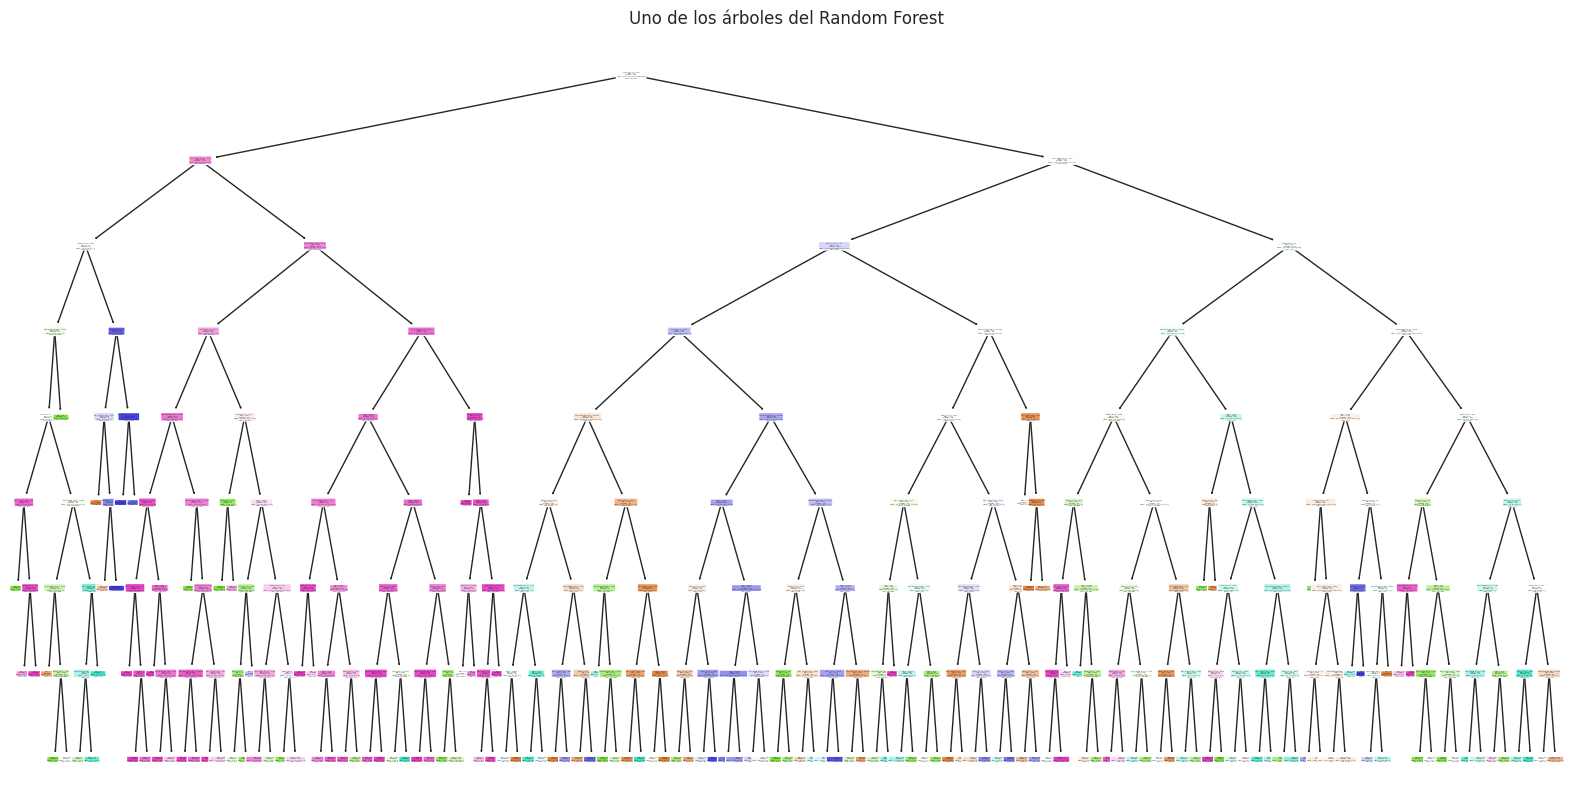

In [ ]:
# ============================================================
# VISUALIZACIÓN DE UN ÁRBOL DEL RANDOM FOREST
# ============================================================
# Seleccionamos uno de los árboles del bosque
tree_from_forest = rf.estimators_[0]
plt.figure(figsize=(20,10))

plot_tree(
    tree_from_forest,
    feature_names=Xcl.columns,
    class_names = dt_SocialMediaP_Class["productivity_level"].unique(),
    filled=True,
    rounded=True
)

plt.title("Uno de los árboles del Random Forest")
plt.show()

#### Evaluación del modelo de Random Forest

In [ ]:
pred_rf = rf.predict(Xcl_test)

print('Accuracy Random Forest:', accuracy_score(ycl_test, pred_rf))
print(classification_report(ycl_test, pred_rf))

Accuracy Random Forest: 0.6391666666666667
              precision    recall  f1-score   support

        Alta       0.58      0.58      0.58       186
        Baja       0.53      0.52      0.53       293
       Media       0.55      0.62      0.58       263
    Muy alta       0.61      0.64      0.63        89
    Muy baja       0.85      0.78      0.81       369

    accuracy                           0.64      1200
   macro avg       0.62      0.63      0.62      1200
weighted avg       0.65      0.64      0.64      1200



##### F-1 Score por clase:
Muy Baja (0.81) El modelo reconoce con facilidad los patrones de baja productividad
Baja y Media (0.53 – 0.58) Son valores muy bajos, esto sugiere que las características que definen la productividad media son muy similares a las de productividad baja o alta, en resumen el modelo se confunde.

##### Precision vs Recall:
En la clase Media el Recall (0.62) es mayor que la precisión (0.55), es decir, el modelo tiende a clasificar más en esta categoría, tomando casos de otras clases.


##### Toma de datos para evaluación de modelo Random Forest versus Red neuronal

Precisión en el conjunto de prueba: 0.6308

Reporte de clasificación:
              precision    recall  f1-score   support

        Alta       0.56      0.54      0.55       186
        Baja       0.52      0.52      0.52       293
       Media       0.54      0.60      0.56       263
    Muy alta       0.63      0.65      0.64        89
    Muy baja       0.84      0.79      0.81       369

    accuracy                           0.63      1200
   macro avg       0.62      0.62      0.62      1200
weighted avg       0.64      0.63      0.63      1200



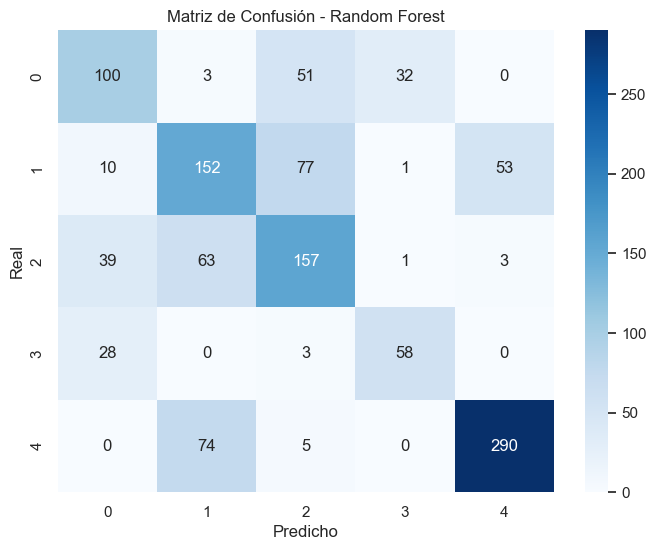

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predicciones
y_pred = rf.predict(Xcl_test)

# Accuracy
accuracy = accuracy_score(ycl_test, y_pred)
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(ycl_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(ycl_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

#####  Hallazgos

De acuerdo con la matriz de confusión y el reporte de clasificación, el modelo Random Forest presenta un desempeño moderado, con una precisión global (accuracy) de 0.64. Si bien el modelo es funcional, evidencia dificultades en la correcta clasificación de los niveles intermedios de productividad.

Se observa un mejor desempeño en las clases extremas, particularmente en _Muy baja_ (288 aciertos) y, en menor medida, _Muy alta_ (57 aciertos). En contraste, las clases intermedias (_Alta, Baja y Media_) presentan una mayor dispersión y confusión entre sí. Por ejemplo, la clase _Alta_ logra 107 aciertos, pero muestra errores relevantes hacia _Media_ (43) y _Muy alta_ (33). De forma similar, la clase _Baja_ presenta confusión principalmente con _Media_ (81 errores) y _Muy baja_ (49 errores).

En general, la matriz de confusión muestra una diagonal poco definida, lo que indica una superposición entre los niveles de productividad y una dificultad del modelo para establecer fronteras claras entre las clases.

Durante el entrenamiento se incluyó la variable `addiction_level` como predictor, considerando su posible relación conductual con la productividad. Si bien esta variable podría presentar cierta correlación con la variable objetivo, los resultados obtenidos no evidencian un sesgo dominante en el modelo, dado que el desempeño general es moderado. Esto sugiere que la predicción del nivel de productividad depende de múltiples variables y no de un único factor explicativo.

### Importancia de variables

In [ ]:
importances = rf.feature_importances_
features = Xcl.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df

,feature,importance
3,study_hours,0.408603
6,focus_score,0.165967
2,social_media_hours,0.137548
4,sleep_hours,0.081931
1,daily_screen_time,0.072118
7,addiction_level,0.065509
5,notifications_per_day,0.038906
0,age,0.029417


<Figure size 640x480 with 0 Axes>

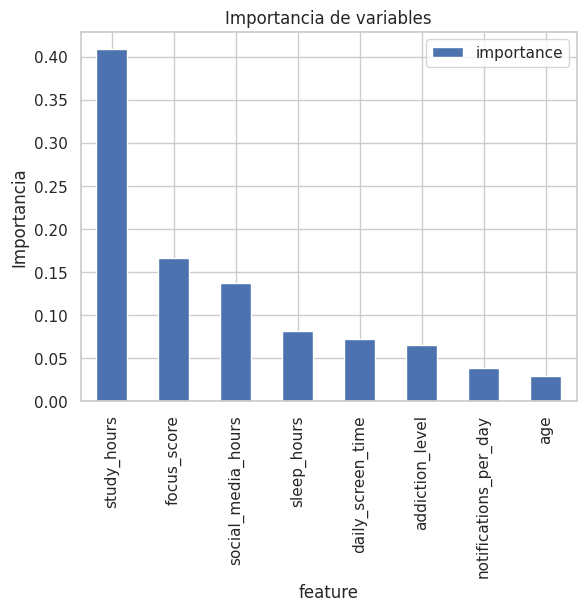

In [ ]:
plt.figure()
importance_df.plot(x='feature', y='importance', kind='bar')
plt.title('Importancia de variables')
plt.ylabel('Importancia')
plt.show()

## Conclusiones de modelo Random Forest

Las variables no permiten diferenciar de forma clara los niveles medios. Es posible que los valores de los registros de productividad _Media_ y _Baja_ sean parecidos.
Hay un sesgo de datos, donde la clase _Baja_ tiene (369 casos) y mejor desempeño porque tiene más ejemplos para aprender.

La discretización (binning) crea límites artificiales, donde el valor de productivity_score puede ser distinto pero sus hábitos casi idénticos (horas de sueño, estudio, entre otros). Este fenómeno genera una pérdida de información y dificulta que el modelo identifique patrones cerca de los límites de cada clase, las variaciones en las variables predictoras, por pequeñas que sean, resultan en cambios drásticos en la variable objetivo.

El ruido en las clases medias puede afectar a una red neuronal. Una manera de mitigar lo anterior sería usar una salida con activación Softmax, mejorando los resultados intermedios.


# Modelo de Redes Neuronales para Clasificación

En esta sección, crearemos un modelo de redes neuronales para clasificar el nivel de productividad ('productivity_level') utilizando el conjunto de datos balanceado con SMOTE. El modelo incluirá al menos dos capas intermedias, como se requiere en el ejercicio.

## Pasos del proceso:
1. **Importación de librerías necesarias**: Importaremos TensorFlow/Keras para construir la red neuronal.
2. **Preparación de datos**: Escalaremos las características y codificaremos la variable objetivo en formato one-hot.
3. **Construcción del modelo**: Crearemos un modelo secuencial con capas densas.
4. **Entrenamiento del modelo**: Entrenaremos el modelo con los datos balanceados.
5. **Evaluación**: Evaluaremos el rendimiento en el conjunto de prueba.

## Importación de librerías para redes neuronales


In [ ]:
# Importación de librerías para redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

## Preparación de datos para el modelo de redes neuronales

In [ ]:
# Preparación de datos para el modelo de redes neuronales

# Escalamos las características
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Codificamos la variable objetivo en one-hot
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_resampled)
y_onehot = to_categorical(y_encoded)

# Dividimos en entrenamiento y validación (usando el conjunto resampleado)
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_resampled_scaled, y_onehot, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Forma del conjunto de entrenamiento: {X_train_nn.shape}")
print(f"Forma del conjunto de validación: {X_val_nn.shape}")
print(f"Número de clases: {y_onehot.shape[1]}")

Forma del conjunto de entrenamiento: (5896, 8)
Forma del conjunto de validación: (1474, 8)
Número de clases: 5


## Construcción del modelo de redes neuronales

In [ ]:
# Construcción del modelo de redes neuronales

model = Sequential()

# Capa de entrada
model.add(Dense(64, input_dim=X_train_nn.shape[1], activation='relu'))

# Primera capa intermedia
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))  # Regularización

# Segunda capa intermedia
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(y_onehot.shape[1], activation='softmax'))

# Compilación del modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Resumen del modelo
model.summary()

c:\Users\elvla\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269 (12.77 KB)

 Trainable params: 3,269 (12.77 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo


In [ ]:
# Entrenamiento del modelo

history = model.fit(
    X_train_nn, y_train_nn,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_nn, y_val_nn),
    verbose=1
)

Epoch 1/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3523 - loss: 1.4026 - val_accuracy: 0.6296 - val_loss: 0.9039
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5534 - loss: 0.9842 - val_accuracy: 0.6689 - val_loss: 0.7784
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6131 - loss: 0.8482 - val_accuracy: 0.6696 - val_loss: 0.7457
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6577 - loss: 0.7957 - val_accuracy: 0.6723 - val_loss: 0.7468
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6574 - loss: 0.7809 - val_accuracy: 0.6825 - val_loss: 0.7320
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6766 - loss: 0.7727 - val_accuracy: 0.6859 - val_loss: 0.7231
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6865 - loss: 0.7597 - val_accuracy: 0.6852 - val_loss: 0.7196
Epoch 8/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6833 - loss: 0.7520 - val_accuracy: 0.

## Evaluación del modelo en el conjunto de prueba


Pérdida en el conjunto de prueba: 0.8220
Precisión en el conjunto de prueba: 0.6417
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

        Alta       0.56      0.59      0.57       186
        Baja       0.55      0.50      0.52       293
       Media       0.55      0.57      0.56       263
    Muy alta       0.59      0.69      0.63        89
    Muy baja       0.84      0.82      0.83       369

    accuracy                           0.64      1200
   macro avg       0.62      0.63      0.62      1200
weighted avg       0.64      0.64      0.64      1200



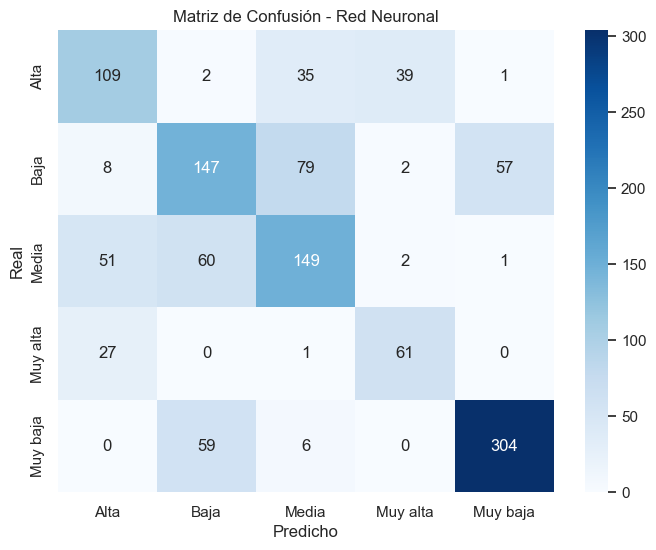

In [ ]:
# Evaluación del modelo en el conjunto de prueba

# Preparamos el conjunto de prueba
X_test_scaled = scaler.transform(Xcl_test)
y_test_encoded = label_encoder.transform(ycl_test)
y_test_onehot = to_categorical(y_test_encoded)

# Evaluamos el modelo
loss, accuracy = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f"Pérdida en el conjunto de prueba: {loss:.4f}")
print(f"Precisión en el conjunto de prueba: {accuracy:.4f}")

# Predicciones
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test_onehot, axis=1)

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test_labels, y_pred, target_names=label_encoder.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Red Neuronal')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## Explicación del Modelo de Redes Neuronales

### Arquitectura del Modelo:
- **Capa de entrada**: 64 neuronas con activación ReLU, correspondiente al número de características escaladas.
- **Primera capa intermedia**: 32 neuronas con ReLU y Dropout (0.2) para evitar sobreajuste.
- **Segunda capa intermedia**: 16 neuronas con ReLU y Dropout (0.2).
- **Capa de salida**: 5 neuronas (una por clase) con activación Softmax para clasificación multiclase.

### Preparación de Datos:
- Las características fueron escaladas usando `StandardScaler` para normalizar los datos.
- La variable objetivo categórica ('productivity_level') fue codificada en one-hot para el entrenamiento.
- Se utilizó el conjunto balanceado con SMOTE para abordar el desbalance de clases.

### Entrenamiento:
- Optimizador: Adam
- Función de pérdida: Categorical Crossentropy (adecuada para clasificación multiclase)
- Métricas: Accuracy
- Épocas: 50
- Batch size: 32
- Validación: 20% del conjunto de entrenamiento balanceado

### Evaluación:
- El modelo se evaluó en el conjunto de prueba original (no balanceado) para medir el rendimiento real.
- Se generó un reporte de clasificación con precisión, recall y F1-score por clase.
- La matriz de confusión visualiza las predicciones correctas e incorrectas.

Este modelo cumple con los requisitos del ejercicio al incluir al menos dos capas intermedias y utilizar SMOTE para balancear las clases antes del entrenamiento.

## Comparación de Rendimiento entre el Modelo Basado en Redes Neuronales y Random Forest Classifier

En este apartado, se realiza una comparación detallada del rendimiento entre el modelo de redes neuronales (NN) y el clasificador Random Forest (RF) para la predicción del nivel de productividad basado en hábitos digitales y de estudio.

### Precisión General
- **Random Forest**: Alcanzó una precisión del 63.08% en el conjunto de prueba.
- **Redes Neuronales**: Obtuvo una precisión ligeramente superior del 64.17% en el mismo conjunto de prueba.

Aunque la diferencia es pequeña (aproximadamente 1.1 puntos porcentuales), el modelo de redes neuronales muestra un rendimiento marginalmente mejor en términos de precisión global.

### Análisis por Clase (Métricas de Clasificación)
Ambos modelos fueron evaluados utilizando métricas de precisión, recall y F1-score para cada una de las cinco clases de productividad: Muy baja, Baja, Media, Alta y Muy alta.

#### Random Forest:
- **Muy baja**: Precisión 0.84, Recall 0.79, F1 0.81 (Excelente para esta clase mayoritaria)
- **Baja**: Precisión 0.52, Recall 0.52, F1 0.52
- **Media**: Precisión 0.54, Recall 0.60, F1 0.56
- **Alta**: Precisión 0.56, Recall 0.54, F1 0.55
- **Muy alta**: Precisión 0.63, Recall 0.65, F1 0.64

#### Redes Neuronales:
- **Muy baja**: Precisión 0.84, Recall 0.82, F1 0.83 (Mejor recall que RF)
- **Baja**: Precisión 0.55, Recall 0.50, F1 0.52
- **Media**: Precisión 0.55, Recall 0.57, F1 0.56
- **Alta**: Precisión 0.56, Recall 0.59, F1 0.57 (Mejor recall que RF)
- **Muy alta**: Precisión 0.59, Recall 0.69, F1 0.63 (Mejor recall, peor precisión que RF)

### Matrices de Confusión
Las matrices de confusión revelan patrones similares de error en ambos modelos:
- Ambos tienen dificultades para distinguir entre clases adyacentes (Baja/Media/Alta).
- La clase "Muy baja" es la mejor clasificada por ambos modelos.
- Las redes neuronales muestran una ligera ventaja en la clasificación de clases minoritarias como "Alta" y "Muy alta".

![](https://photos.fife.usercontent.google.com/pw/AP1GczMYGbWugUWrpryOa1MckzJwhw8gpEc_MJzjUyWyDrWG6QpnclJJpR09=w1280-h720-s-no-gm?authuser=0)
_Figura 1. Comparación de matrices de confusión obtenidas en a) Random forest y b) Red Neuronal._

### Consideraciones Adicionales
- **Complejidad del Modelo**: El Random Forest es más interpretable y rápido de entrenar, mientras que las redes neuronales requieren más recursos computacionales pero pueden capturar relaciones no lineales más complejas.
- **Balance de Clases**: Ambos modelos utilizaron técnicas de balanceo (SMOTE + undersampling), lo que ayudó a mejorar el rendimiento en clases minoritarias.
- **Consistencia**: Las diferencias en rendimiento son mínimas, sugiriendo que ambos enfoques son viables para este problema de clasificación.

En conclusión, aunque las redes neuronales ofrecen un rendimiento ligeramente superior, la elección entre ambos modelos dependerá de factores como la interpretabilidad requerida, recursos disponibles y la necesidad de ajuste fino del modelo.

# Evaluación grupal

De común acuerdo, el equipo decidio incluir una sola tabla de evaluación grupal:

|                                                                                 | Sí | No | A veces |
| ------------------------------------------------------------------------------- | -- | -- | ------- |
| Todos los miembros se han integrado al trabajo del grupo                        |   x |    |         |
| Todos los miembros participan activamente                                       |   x |    |         |
| Todos los miembros respetan otras ideas aportadas                               |  x  |    |         |
| Todos los miembros participan en la elaboración del informe                     |  x  |    |         |
| Me he preocupado por realizar un trabajo cooperativo con mis compañeros         |  x  |    |         |
| Señala si consideras que algún aspecto del trabajo en grupo no ha sido adecuado |  no aplica  |    |         |